# 2.6 Visualization of functional enrichment results (2)

Author: Xuezhu Sunny Wang

## Dataset 📊

- Gene lists of gene expression programs from cNMF analysis

## Steps overview 📒
- Run GO BP enrichment for gene lists
- Plot the results


In [1]:
marker_table <- read.csv("plasma_cnmf_3_topgenes_withoutIG_k=13.csv")
marker_table 

X,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
0,DHRS9,CD19,MS4A1,CFHR1,AC233755.1,PPP1R14A,WFDC2,AC233755.2,S100A9,NRGN,RRM2,C1QB,TRBC1
1,NEB,RNASE6,CCL3,AC246787.2,LY6K,CST6,G0S2,TMEM176B,LYZ,TUBB1,MKI67,C1QC,GNLY
2,PTP4A3,CD27,FGF7,FAM30A,GPR15,SPON2,CRIP1,NSD2,FCN1,PPBP,TYMS,APOE,FGFBP2
3,AL353753.1,HLA-DPA1,LAPTM5,CTSW,SLC2A5,CGREF1,LAMP5,TMEM176A,VCAN,GP9,STMN1,C1QA,NKG7
4,NUDT12,HLA-DQB1,CPVL,SLC22A17,DDIT4,TMEM119,MT1E,AZGP1,S100A8,MPIG6B,UBE2C,APOC1,KLRB1
5,ISLR,HLA-DRB5,ALOX5AP,JCHAIN,AKAP12,CLDN3,MT2A,KLF4,MNDA,CAVIN2,TOP2A,CD5L,KLRC1
6,LINC01088,CD79A,BTG1,SPINK2,CTSW,TRPM4,LINC01480,AREG,LST1,PF4,TPX2,VCAM1,S1PR5
7,HIST1H1C,HLA-DRB1,ZFP36L2,RBP1,ID3,OBP2A,CAVIN3,DNAAF1,FYB1,AL731557.1,NUSAP1,HMOX1,GZMM
8,MT-ND5,HLA-DMA,CCL4,CADPS2,GRASP,PHACTR3,PLTP,SOCS3,FCER1G,TMEM40,BIRC5,CCL18,GZMA


In [2]:
marker_table$X<-NULL

In [3]:
library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)
library(dplyr)

# Store all enrichment results
all_marker_enrichment <- list()

# Loop through each gene signature (column)
for (marker_name in colnames(marker_table)) {
  cat("Processing marker set:", marker_name, "\n")
  
  # Get the gene list from the column, remove NA
  geneList <- na.omit(marker_table[[marker_name]])
  
  # Skip empty sets
  if (length(geneList) < 3) {
    cat("Too few genes for enrichment in", marker_name, "\n")
    next
  }

  # Convert to Entrez ID
  gene.df <- bitr(geneList, fromType = "SYMBOL",
                  toType = "ENTREZID",
                  OrgDb = org.Hs.eg.db)

  if (nrow(gene.df) < 3) {
    cat("No valid Entrez IDs found for", marker_name, "\n")
    next
  }

  # Run enrichment
  ego <- enrichGO(gene = gene.df$ENTREZID,
                  OrgDb = org.Hs.eg.db,
                  keyType = "ENTREZID",
                  ont = "BP",
                  pvalueCutoff = 0.05,
                  qvalueCutoff = 0.2,
                  pAdjustMethod = "BH",
                  readable = TRUE)

  # Store results
  if (!is.null(ego) && nrow(as.data.frame(ego)) > 0) {
    ego_df <- as.data.frame(ego)
    ego_df$marker <- marker_name
    all_marker_enrichment[[marker_name]] <- ego_df
  } else {
    cat("No significant enrichment for", marker_name, "\n")
  }
}

# Combine all results into one table
combined_marker_enrichment <- bind_rows(all_marker_enrichment)

# Save to file
write.csv(combined_marker_enrichment, "GO_BP_enrichment_marker_sets-cnmf.csv", row.names = FALSE)

# Preview
head(combined_marker_enrichment)




Registered S3 methods overwritten by 'treeio':
  method              from    
  MRCA.phylo          tidytree
  MRCA.treedata       tidytree
  Nnode.treedata      tidytree
  Ntip.treedata       tidytree
  ancestor.phylo      tidytree
  ancestor.treedata   tidytree
  child.phylo         tidytree
  child.treedata      tidytree
  full_join.phylo     tidytree
  full_join.treedata  tidytree
  groupClade.phylo    tidytree
  groupClade.treedata tidytree
  groupOTU.phylo      tidytree
  groupOTU.treedata   tidytree
  inner_join.phylo    tidytree
  inner_join.treedata tidytree
  is.rooted.treedata  tidytree
  nodeid.phylo        tidytree
  nodeid.treedata     tidytree
  nodelab.phylo       tidytree
  nodelab.treedata    tidytree
  offspring.phylo     tidytree
  offspring.treedata  tidytree
  parent.phylo        tidytree
  parent.treedata     tidytree
  root.treedata       tidytree
  rootnode.phylo      tidytree
  sibling.phylo       tidytree

clusterProfiler v4.10.1  For help: https://yulab-sm

Processing marker set: X1 


'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(geneList, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db):
“15% of input gene IDs are fail to map...”


Processing marker set: X2 


'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(geneList, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db):
“3% of input gene IDs are fail to map...”


...

Processing marker set: X12 


'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(geneList, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db):
“6% of input gene IDs are fail to map...”


Processing marker set: X13 


'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(geneList, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db):
“10% of input gene IDs are fail to map...”


,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,marker
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>
GO:0002181,GO:0002181,cytoplasmic translation,18/79,156/18870,2.129638e-21,4.001589e-18,3.385003e-18,RPL36A/RPS17/RPL13A/RPL37/RPL23/RPL24/RPL7/RPL36/UBA52/RPL37A/RPS11/RPL31/RPL10A/RPL35/RPL21/RPL27A/RPL38/RACK1,18,X1
GO:0042273,GO:0042273,ribosomal large subunit biogenesis,6/79,76/18870,7.687756e-07,7.222646e-04,6.109743e-04,RPL24/RPL7/NPM1/RPL10A/RPL35/RPL38,6,X1
GO:0043086...3,GO:0043086,negative regulation of catalytic activity,10/79,480/18870,3.093206e-05,1.937378e-02,1.638857e-02,RPL23/IFI6/NES/GAS6/HGF/TGFB2/NPM1/PARP9/GAPDH/ANXA1,10,X1
GO:0042254,GO:0042254,ribosome biogenesis,8/79,325/18870,6.407502e-05,2.902440e-02,2.455216e-02,RPS17/RPL24/RPL7/RPS11/NPM1/RPL10A/RPL35/RPL38,8,X1
GO:1901796,GO:1901796,regulation of signal transduction by p53 class mediator,5/79,107/18870,8.617077e-05,2.902440e-02,2.455216e-02,RPL37/RPL23/MYC/NPM1/MUC1,5,X1
GO:0072331,GO:0072331,signal transduction by p53 class mediator,6/79,175/18870,9.268035e-05,2.902440e-02,2.455216e-02,RPL37/RPL23/PERP/MYC/NPM1/MUC1,6,X1


In [4]:
# Load packages
library(ggplot2)
library(readr)
library(dplyr)

df<-read.csv('GO_BP_enrichment_marker_sets-cnmf.csv')
df$Descrtiption<-paste(df$ID,df$Description,sep=':')
df

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,marker,Descrtiption
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>
GO:0002181,cytoplasmic translation,18/79,156/18870,2.129638e-21,4.001589e-18,3.385003e-18,RPL36A/RPS17/RPL13A/RPL37/RPL23/RPL24/RPL7/RPL36/UBA52/RPL37A/RPS11/RPL31/RPL10A/RPL35/RPL21/RPL27A/RPL38/RACK1,18,X1,GO:0002181:cytoplasmic translation
GO:0042273,ribosomal large subunit biogenesis,6/79,76/18870,7.687756e-07,7.222646e-04,6.109743e-04,RPL24/RPL7/NPM1/RPL10A/RPL35/RPL38,6,X1,GO:0042273:ribosomal large subunit biogenesis
GO:0043086,negative regulation of catalytic activity,10/79,480/18870,3.093206e-05,1.937378e-02,1.638857e-02,RPL23/IFI6/NES/GAS6/HGF/TGFB2/NPM1/PARP9/GAPDH/ANXA1,10,X1,GO:0043086:negative regulation of catalytic activity
GO:0042254,ribosome biogenesis,8/79,325/18870,6.407502e-05,2.902440e-02,2.455216e-02,RPS17/RPL24/RPL7/RPS11/NPM1/RPL10A/RPL35/RPL38,8,X1,GO:0042254:ribosome biogenesis
GO:1901796,regulation of signal transduction by p53 class mediator,5/79,107/18870,8.617077e-05,2.902440e-02,2.455216e-02,RPL37/RPL23/MYC/NPM1/MUC1,5,X1,GO:1901796:regulation of signal transduction by p53 class mediator
GO:0072331,signal transduction by p53 class mediator,6/79,175/18870,9.268035e-05,2.902440e-02,2.455216e-02,RPL37/RPL23/PERP/MYC/NPM1/MUC1,6,X1,GO:0072331:signal transduction by p53 class mediator
GO:2000630,positive regulation of miRNA metabolic process,4/79,64/18870,1.493918e-04,3.935374e-02,3.328990e-02,GAS5/NEAT1/MYC/TGFB2,4,X1,GO:2000630:positive regulation of miRNA metabolic process
GO:2000116,regulation of cysteine-type endopeptidase activity,6/79,195/18870,1.675518e-04,3.935374e-02,3.328990e-02,IFI6/PERP/GAS6/MYC/HGF/RACK1,6,X1,GO:2000116:regulation of cysteine-type endopeptidase activity
GO:0052548,regulation of endopeptidase activity,7/79,288/18870,2.034391e-04,4.031333e-02,3.410164e-02,IFI6/PERP/GAS6/MYC/HGF/GAPDH/RACK1,7,X1,GO:0052548:regulation of endopeptidase activity


In [1]:
# Load packages
library(ggplot2)
library(readr)
library(dplyr)

df<-read.csv('GO_BP_enrichment_marker_sets-cnmf-selected-2.csv')
df$Descrtiption<-paste(df$ID,df$Description,sep=':')
df


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,marker,Descrtiption
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>
GO:0002181,cytoplasmic translation,18/79,156/18870,2.129638e-21,4.001589e-18,3.385003e-18,RPL36A/RPS17/RPL13A/RPL37/RPL23/RPL24/RPL7/RPL36/UBA52/RPL37A/RPS11/RPL31/RPL10A/RPL35/RPL21/RPL27A/RPL38/RACK1,18,X1,GO:0002181:cytoplasmic translation
GO:0042273,ribosomal large subunit biogenesis,6/79,76/18870,7.687756e-07,7.222650e-04,6.109740e-04,RPL24/RPL7/NPM1/RPL10A/RPL35/RPL38,6,X1,GO:0042273:ribosomal large subunit biogenesis
GO:0052548,regulation of endopeptidase activity,7/79,288/18870,2.034390e-04,4.031333e-02,3.410164e-02,IFI6/PERP/GAS6/MYC/HGF/GAPDH/RACK1,7,X1,GO:0052548:regulation of endopeptidase activity
GO:2000116,regulation of cysteine-type endopeptidase activity,6/79,195/18870,1.675520e-04,3.935374e-02,3.328991e-02,IFI6/PERP/GAS6/MYC/HGF/RACK1,6,X1,GO:2000116:regulation of cysteine-type endopeptidase activity
GO:0050871,positive regulation of B cell activation,6/92,84/18870,3.410183e-06,1.675860e-04,1.345610e-04,CD27/CD74/XBP1/CD81/CD38/SYK,6,X2,GO:0050871:positive regulation of B cell activation
GO:0032527,protein exit from endoplasmic reticulum,5/92,48/18870,3.581702e-06,1.711260e-04,1.374030e-04,CD81/HSP90B1/SEC13/UBE2J1/ERLEC1,5,X2,GO:0032527:protein exit from endoplasmic reticulum
GO:0042100,B cell proliferation,6/92,104/18870,1.177441e-05,5.192820e-04,4.169510e-04,CD19/CD79A/CD74/CD81/CD38/MZB1,6,X2,GO:0042100:B cell proliferation
GO:0045579,positive regulation of B cell differentiation,3/92,16/18870,5.998279e-05,1.984046e-03,1.593065e-03,CD27/XBP1/SYK,3,X2,GO:0045579:positive regulation of B cell differentiation
GO:0002503,peptide antigen assembly with MHC class II protein complex,6/92,16/18870,8.763958e-11,2.201979e-08,1.768052e-08,HLA-DPA1/HLA-DQB1/HLA-DRB5/HLA-DRB1/HLA-DMA/HLA-DQA1,6,X2,GO:0002503:peptide antigen assembly with MHC class II protein complex


In [2]:
table(df$marker)


 X1 X11  X2  X3  X4  X6  X7  X8  X9 
  4   5   5   4   5   3   5   3   5 

Loading required package: viridisLite



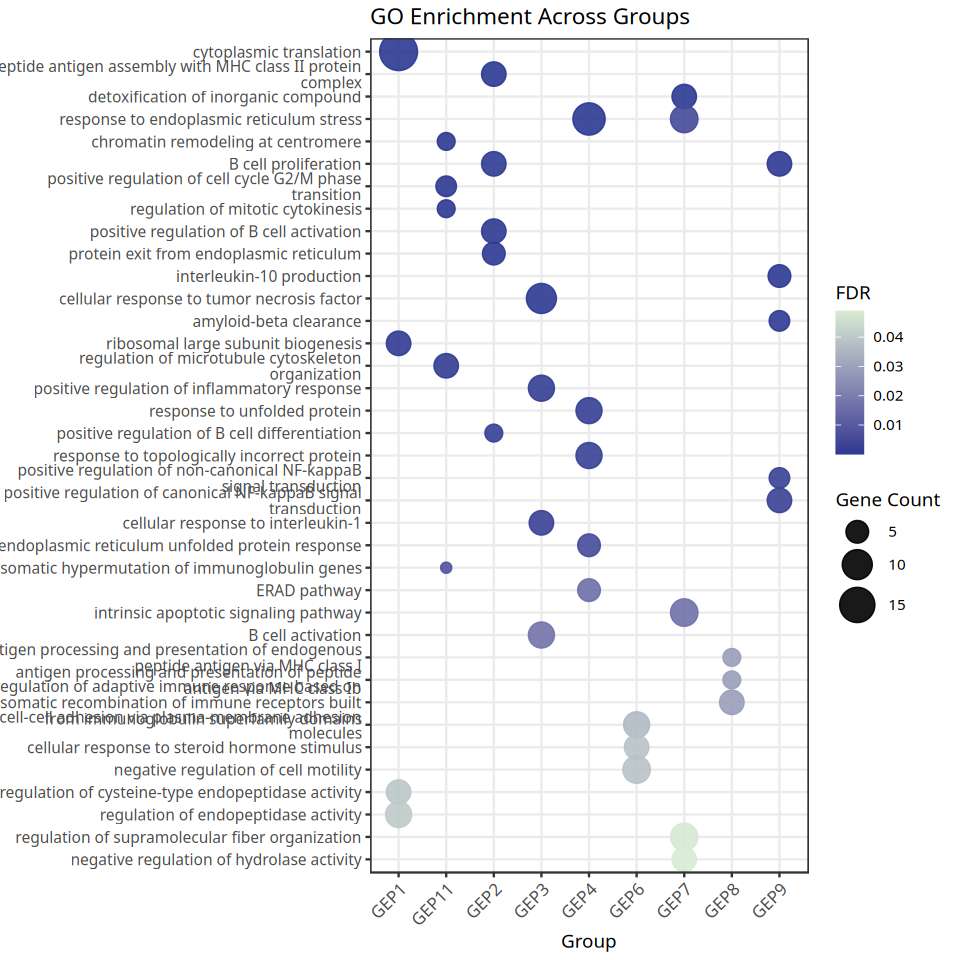

In [3]:
library(dplyr)
library(tidyr)
library(stringr)
library(forcats)
library(ggplot2)
library(viridis)

top_n <- 15

df_top <- df%>%
  group_by(marker) %>%
  slice_min(p.adjust, n = top_n, with_ties = FALSE) %>%
  ungroup() %>%
  mutate(
    term = str_wrap(Description, width = 50)
  )

# Order terms globally by their best (lowest) p.adjust so important ones appear centered
term_order <- df_top %>%
  group_by(term) %>%
  summarize(best_p = suppressWarnings(min(p.adjust, na.rm = TRUE))) %>%
  arrange(best_p) %>%
  pull(term)

df_top <- df_top %>%
  mutate(
    term = factor(term, levels = rev(term_order)),        # y order
    marker = factor(marker)                               # x order (customize if you want)
  )

df_top$marker<-gsub('X','GEP',df_top$marker)

options(repr.plot.height = 8, repr.plot.width = 8)
ggplot(df_top, aes(x = marker, y = term)) +
  geom_point(aes(size = Count, color = p.adjust), alpha = 0.9) +
  scale_color_gradient(high = "#d9ecd3",low = "#2c3991", name = "FDR") +
  scale_size(range = c(2.5, 10), name = "Gene Count") +
  labs(x = "Group", y = NULL, title = "GO Enrichment Across Groups") +
  theme_bw() +
  theme(
    axis.text.y = element_text(size = 9),
    axis.text.x = element_text(size = 10, angle = 45, hjust = 1),
    plot.margin = margin(t = 5, r = 10, b = 5, l = 10)
  )


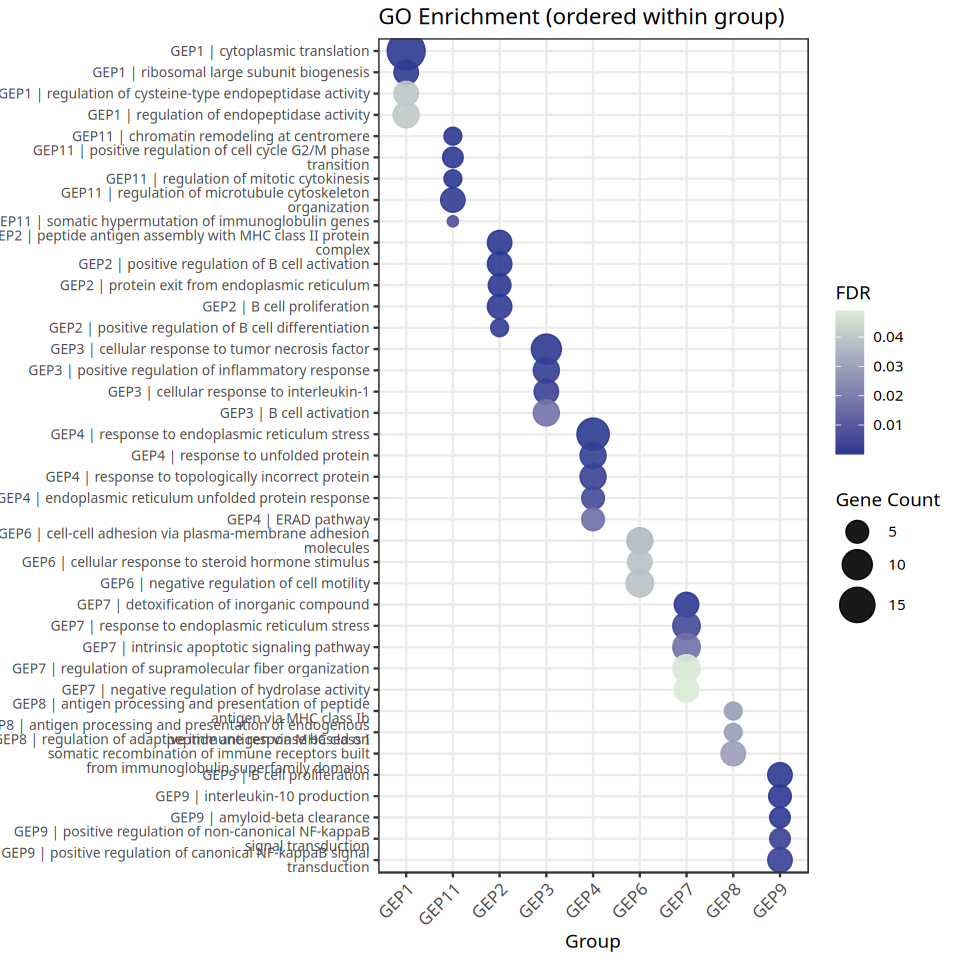

In [4]:
library(dplyr)
library(stringr)
library(ggplot2)
library(forcats)

top_n <- 15

df_top <- df %>%
  mutate(marker = gsub("X", "GEP", marker)) %>%
  group_by(marker) %>%
  slice_min(p.adjust, n = top_n, with_ties = FALSE) %>%
  arrange(marker, p.adjust) %>%
  mutate(
    term = str_wrap(Description, 50),
    term_y = paste0(marker, " | ", term)  # marker-specific y labels
  ) %>%
  ungroup() %>%
  mutate(
    term_y = factor(term_y, levels = rev(unique(term_y))),
    marker = factor(marker)
  )

options(repr.plot.height = 8, repr.plot.width = 8)

ggplot(df_top, aes(x = marker, y = term_y)) +
  geom_point(aes(size = Count, color = p.adjust), alpha = 0.9) +
  scale_color_gradient(high = "#d9ecd3", low = "#2c3991", name = "FDR") +
  scale_size(range = c(2.5, 10), name = "Gene Count") +
  labs(x = "Group", y = NULL, title = "GO Enrichment (ordered within group)") +
  theme_bw() +
  theme(
    axis.text.y = element_text(size = 8),
    axis.text.x = element_text(size = 10, angle = 45, hjust = 1),
    plot.margin = margin(t = 5, r = 10, b = 5, l = 10)
  )


In [5]:
p <- ggplot(df_top, aes(x = marker, y = term_y)) +
  geom_point(aes(size = Count, color = p.adjust), alpha = 0.9) +
  scale_color_gradient(high = "firebrick", low = "pink1", name = "FDR") +
  scale_size(range = c(2.5, 10), name = "Gene Count") +
  labs(x = "Group", y = NULL, title = "GO Enrichment (ordered within group)") +
  theme_bw() +
  theme(
    axis.text.y = element_text(size = 8),
    axis.text.x = element_text(size = 10, angle = 45, hjust = 1),
    plot.margin = margin(t = 5, r = 10, b = 5, l = 10)
  )

ggsave("Fig2e.pdf", plot = p, width = 8, height = 8)
